In [1]:
# ==============================================================================
# Step 1: Import Required Libraries
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Create charts directory
os.makedirs('../charts', exist_ok=True)

print("Step 1 Completed: Required libraries imported and '../charts' directory created.")
print("Key Finding: Environment is successfully set up for EDA and Data Cleaning.\n")


Step 1 Completed: Required libraries imported and '../charts' directory created.
Key Finding: Environment is successfully set up for EDA and Data Cleaning.



In [2]:
# ==============================================================================
# Step 2: Load Data
# ==============================================================================
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Step 2 Completed: Data loaded. Train shape: {train_df.shape}, Test shape: {test_df.shape}.")
print("Key Finding: Datasets successfully loaded into pandas DataFrames.\n")


Step 2 Completed: Data loaded. Train shape: (750000, 18), Test shape: (250000, 17).
Key Finding: Datasets successfully loaded into pandas DataFrames.



In [3]:
# ==============================================================================
# Step 3: Check for Duplicates & Missing Values (NaN)
# ==============================================================================
# Duplicates
train_duplicates = train_df.duplicated().sum()
if train_duplicates > 0:
    print(f"{train_duplicates} duplicate value(s) found. Removing duplicates...")
    train_df = train_df.drop_duplicates()
else:
    print("No duplicate values found.")

# Missing Values
missing_values = train_df.isnull().sum().sum()
if missing_values > 0:
    print(f"{missing_values} NaN value(s) found in the dataset.")
else:
    print("No NaN values found in the dataset.")

print("Step 3 Completed: Duplicate and missing value check finished.")
print(f"Key Finding: The dataset is highly populated with {missing_values} missing values and {train_duplicates} duplicates handled.\n")


No duplicate values found.
No NaN values found in the dataset.
Step 3 Completed: Duplicate and missing value check finished.
Key Finding: The dataset is highly populated with 0 missing values and 0 duplicates handled.



In [4]:
# ==============================================================================
# Step 4: Data Cleaning (Extra spaces, lower case, replace space with underscore)
# ==============================================================================
def clean_dataframe(df):
    # Clean column names
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    # Clean string column values
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.lower().str.strip().str.replace(' ', '_')
    return df

train_df = clean_dataframe(train_df)
test_df = clean_dataframe(test_df)

print("Step 4 Completed: Data cleaning applied (lowercased, spaces stripped and replaced with underscores).")
print("Key Finding: Dataset text features are now standardized, preventing case-sensitive or whitespace mismatch errors.\n")


Step 4 Completed: Data cleaning applied (lowercased, spaces stripped and replaced with underscores).
Key Finding: Dataset text features are now standardized, preventing case-sensitive or whitespace mismatch errors.



In [5]:
# ==============================================================================
# Step 5: Identify Numerical, Categorical, and Target Columns
# ==============================================================================
if 'id' in train_df.columns:
    train_df = train_df.drop(columns=['id'])
    
TARGET = 'y'
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

print(f"Step 5 Completed: Columns identified.")
print(f"Numerical ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Target: {TARGET}")
print("Key Finding: Features have been successfully partitioned by data type for specific EDA techniques.\n")


Step 5 Completed: Columns identified.
Numerical (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Target: y
Key Finding: Features have been successfully partitioned by data type for specific EDA techniques.



In [6]:
# ==============================================================================
# Step 5b: Dataset Overview & Metadata
# ==============================================================================
print("==============================================================================")
print("Dataset Overview & Metadata")
print("==============================================================================")
print(f"1. Dataset source: Bank Marketing Competition Dataset")
print(f"2. Domain description: Direct marketing campaigns (e.g., phone calls) for a financial institution predicting customer subscription.")
print(f"3. Number of observations:")
print(f"   - Training set: {train_df.shape[0]} rows")
print(f"   - Test set: {test_df.shape[0]} rows")
print(f"4. Number of features: {train_df.shape[1] - 1} predictor features")
print(f"5. Target variable: '{TARGET}'")
print(f"6. Feature categories: {len(numerical_cols)} Numerical features, {len(categorical_cols)} Categorical features")

print("\nStep 5b Completed: Dataset metadata extracted.\n")

Dataset Overview & Metadata
1. Dataset source: Bank Marketing Competition Dataset
2. Domain description: Direct marketing campaigns (e.g., phone calls) for a financial institution predicting customer subscription.
3. Number of observations:
   - Training set: 750000 rows
   - Test set: 250000 rows
4. Number of features: 16 predictor features
5. Target variable: 'y'
6. Feature categories: 7 Numerical features, 9 Categorical features

Step 5b Completed: Dataset metadata extracted.



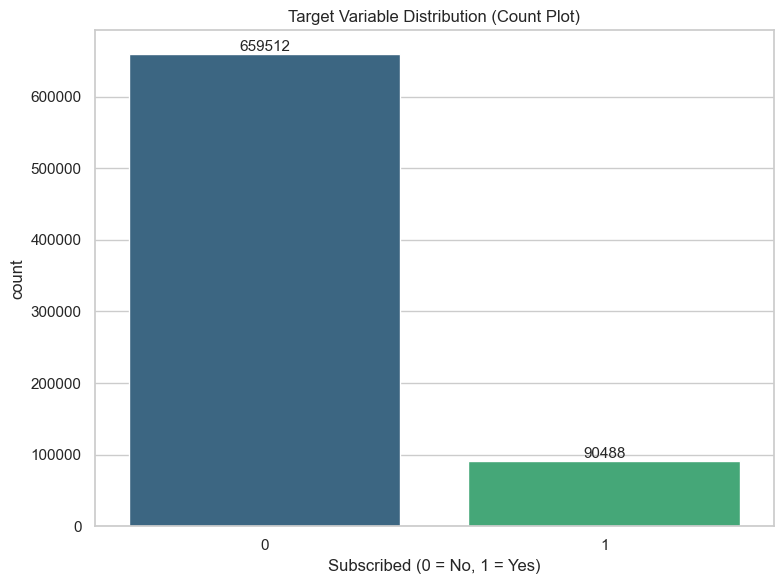

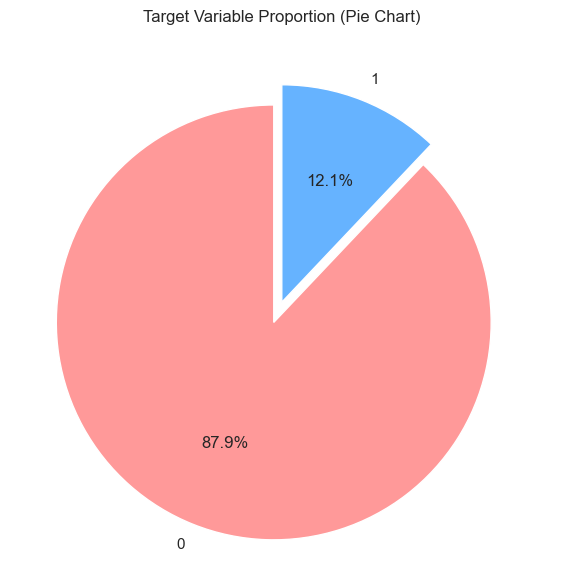

Step 6 Completed: Target distribution visualized with separate Count Plot and Pie Chart.
Key Finding: There is a significant class imbalance (approx 88% No, 12% Yes). Models will need class weighting or SMOTE.



In [7]:
# ==============================================================================
# Step 6: Target Variable Distribution (Count Plot & Pie Chart)
# ==============================================================================
# 6A: Count Plot with Values
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=train_df, x=TARGET, palette='viridis')
plt.title("Target Variable Distribution (Count Plot)")
plt.xlabel("Subscribed (0 = No, 1 = Yes)")

# Display the exact count number and percentage on the bars
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../charts/01a_Target_Countplot.png', bbox_inches='tight')
plt.show()
plt.close()

# 6B: Pie Chart for Proportions
plt.figure(figsize=(8, 6))
target_counts = train_df[TARGET].value_counts()
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.1, 0))
plt.title("Target Variable Proportion (Pie Chart)")
plt.tight_layout()
plt.savefig('../charts/01b_Target_PieChart.png', bbox_inches='tight')
plt.show()
plt.close()

print("Step 6 Completed: Target distribution visualized with separate Count Plot and Pie Chart.")
print("Key Finding: There is a significant class imbalance (approx 88% No, 12% Yes). Models will need class weighting or SMOTE.\n")


In [8]:
# ==============================================================================
# Step 7: Numerical Feature Summary
# ==============================================================================
display(train_df[numerical_cols].describe().T)
print("Step 7 Completed: Numerical feature summary statistics generated.")
print("Key Finding: Variances across numerical columns (like balance and duration) indicate that feature scaling will be necessary.\n")


,count,mean,std,min,25%,50%,75%,max
age,750000.0,40.926395,10.098829,18.0,33.0,39.0,48.0,95.0
balance,750000.0,1204.067397,2836.096759,-8019.0,0.0,634.0,1390.0,99717.0
day,750000.0,16.117209,8.250832,1.0,9.0,17.0,21.0,31.0
duration,750000.0,256.229144,272.555662,1.0,91.0,133.0,361.0,4918.0
campaign,750000.0,2.577008,2.718514,1.0,1.0,2.0,3.0,63.0
pdays,750000.0,22.412733,77.319998,-1.0,-1.0,-1.0,-1.0,871.0
previous,750000.0,0.298545,1.335926,0.0,0.0,0.0,0.0,200.0


Step 7 Completed: Numerical feature summary statistics generated.
Key Finding: Variances across numerical columns (like balance and duration) indicate that feature scaling will be necessary.



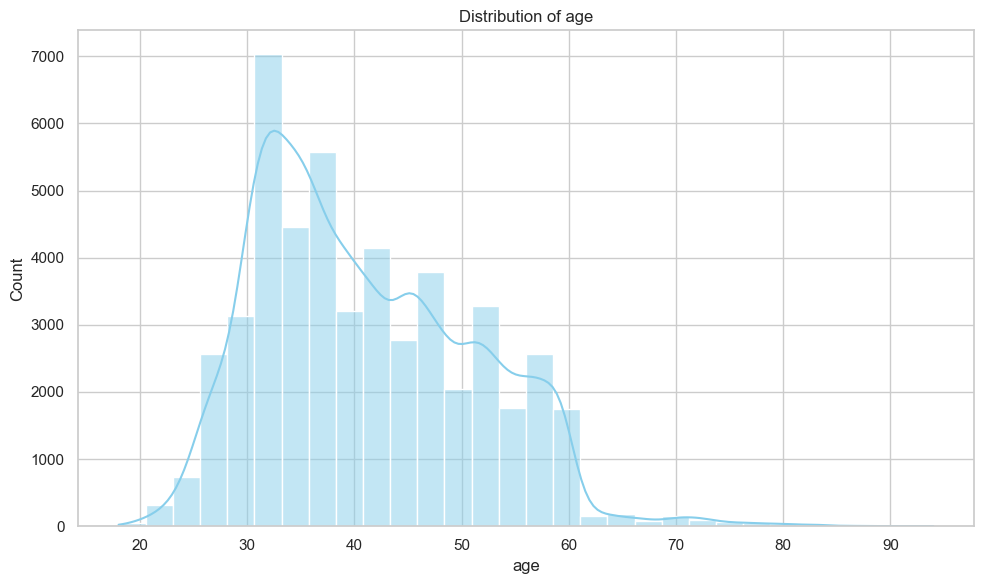

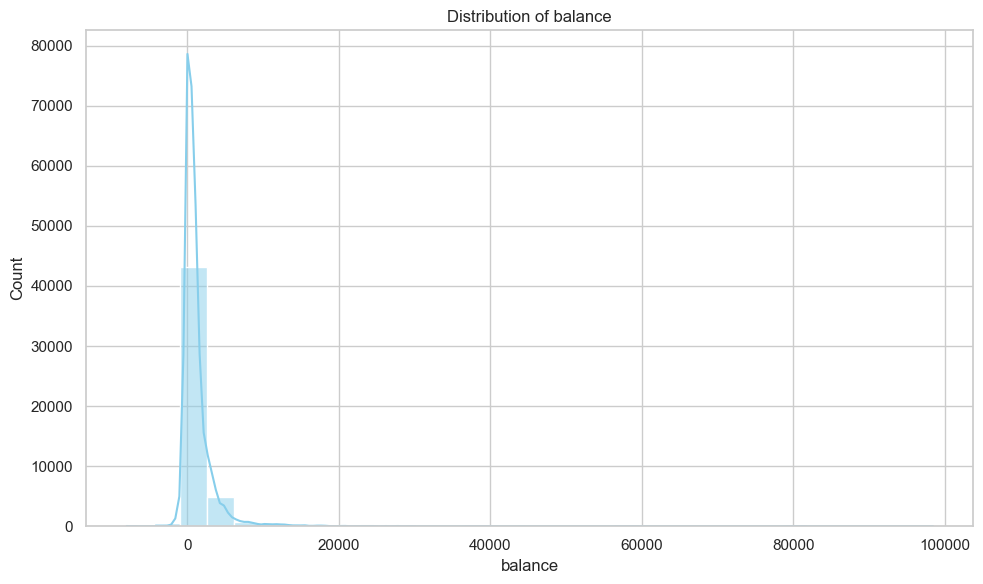

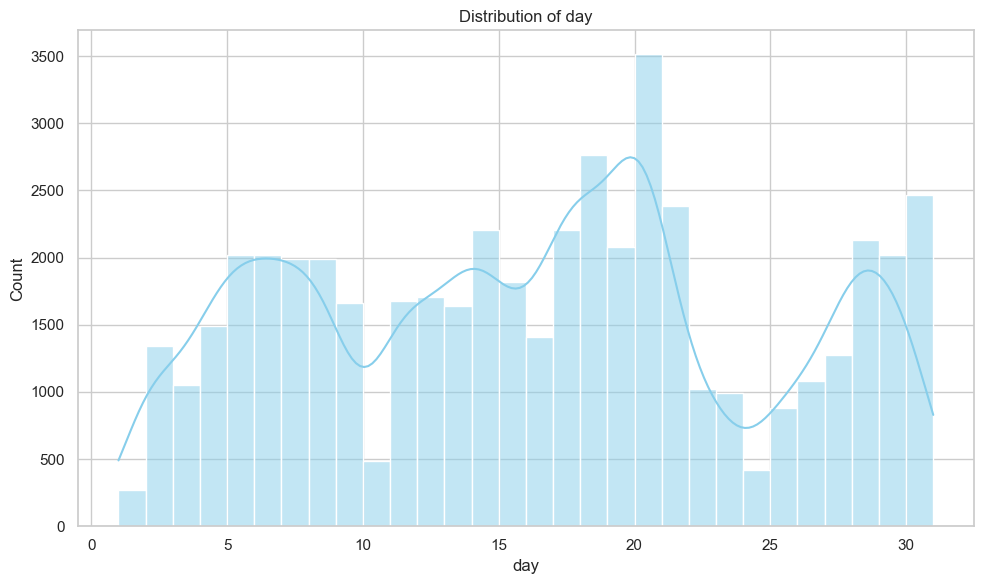

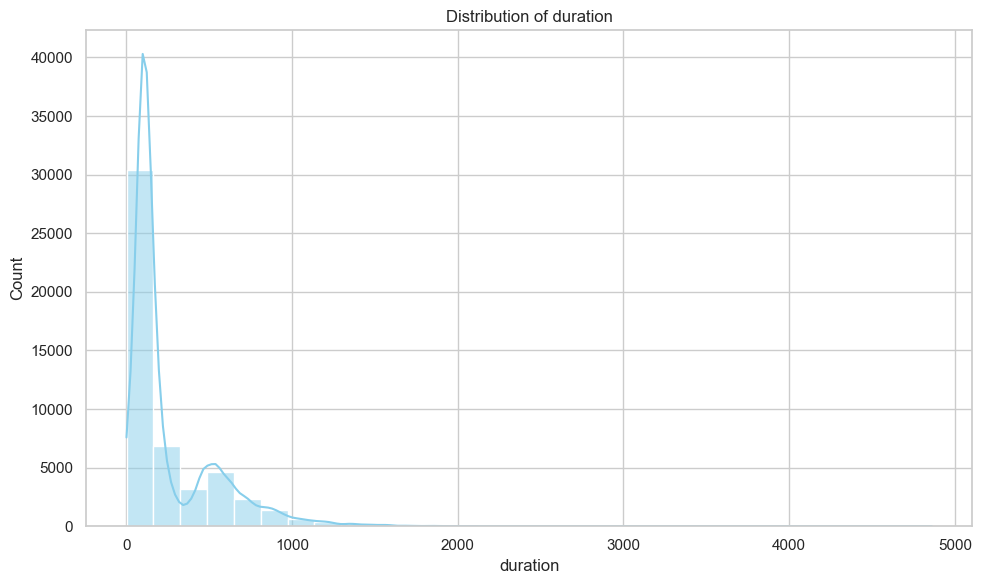

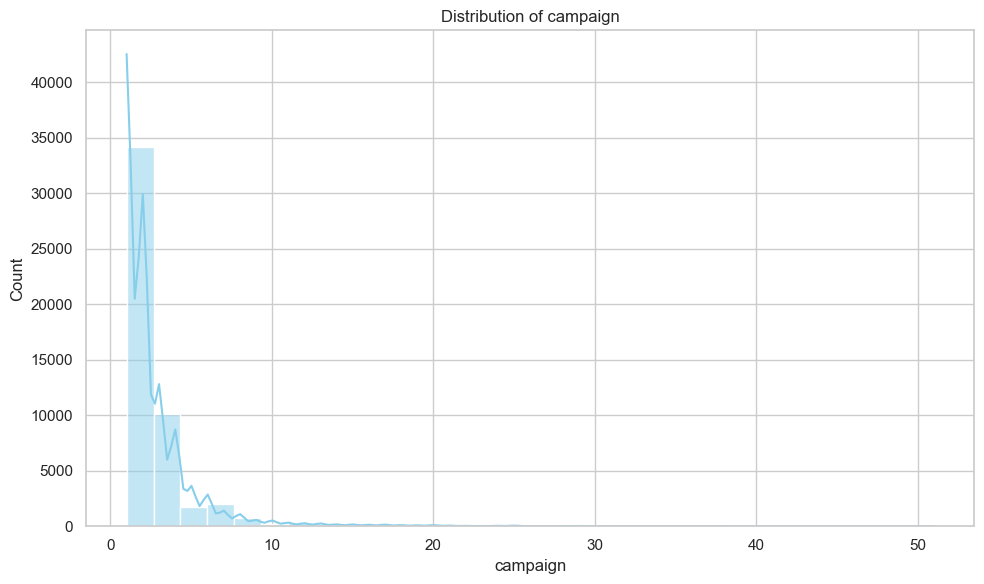

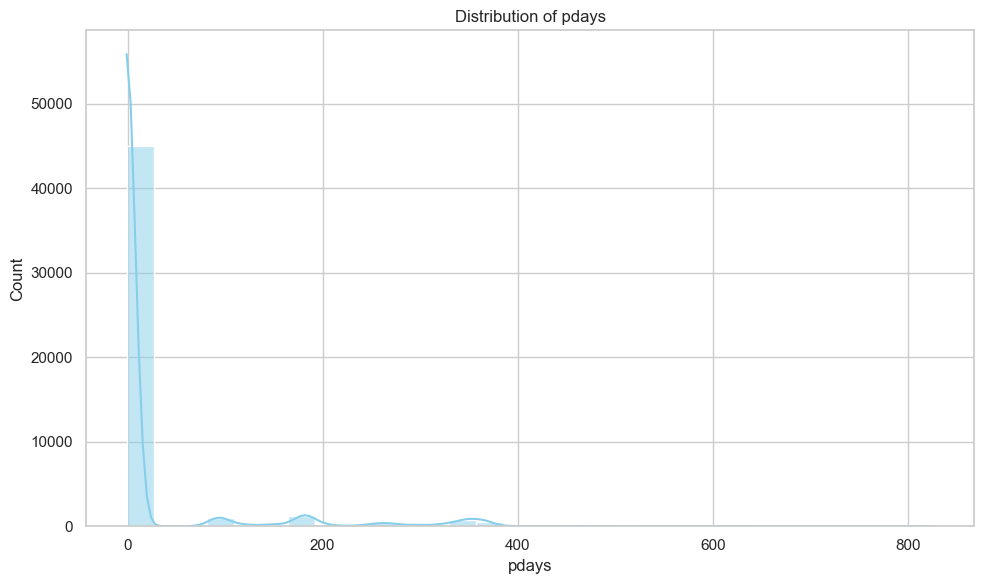

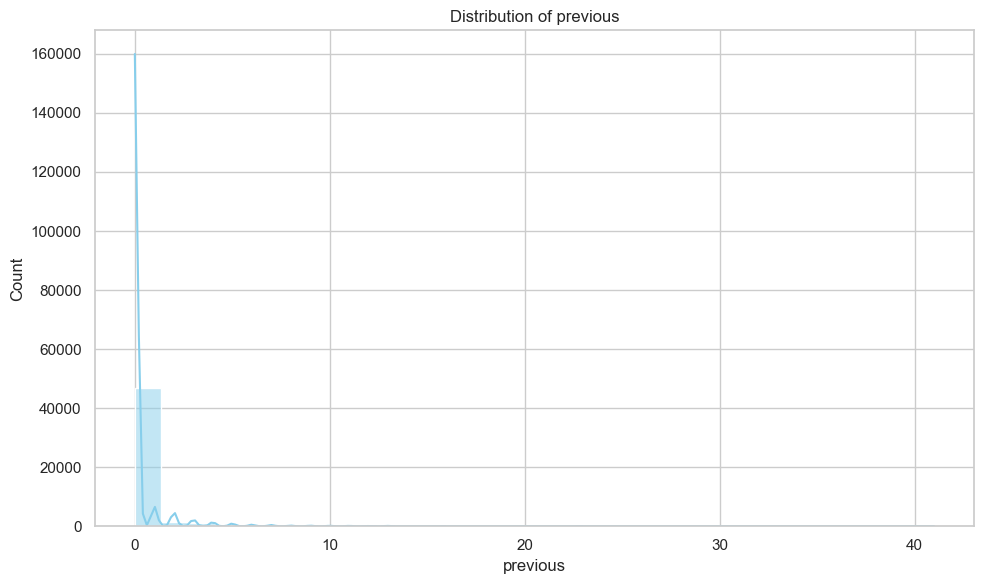

Step 8 Completed: Individual numerical distributions plotted and saved.
Key Finding: Several numerical features (balance, duration, campaign, pdays) are heavily right-skewed.



In [9]:
# ==============================================================================
# Step 8: Numerical Feature Distributions: Histograms + KDE (Separate Graphs)
# ==============================================================================
sample_df = train_df.sample(n=min(50000, len(train_df)), random_state=42) # Sampled for speed

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=sample_df, x=col, kde=True, color='skyblue', bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.savefig(f'../charts/02_Num_Dist_{col}.png', bbox_inches='tight')
    plt.show()
    plt.close()

print("Step 8 Completed: Individual numerical distributions plotted and saved.")
print("Key Finding: Several numerical features (balance, duration, campaign, pdays) are heavily right-skewed.\n")


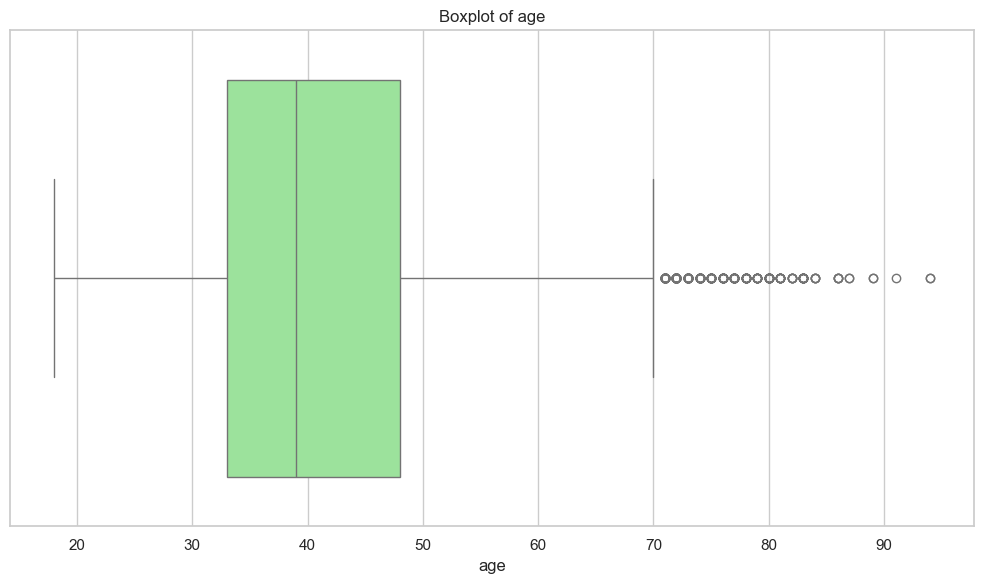

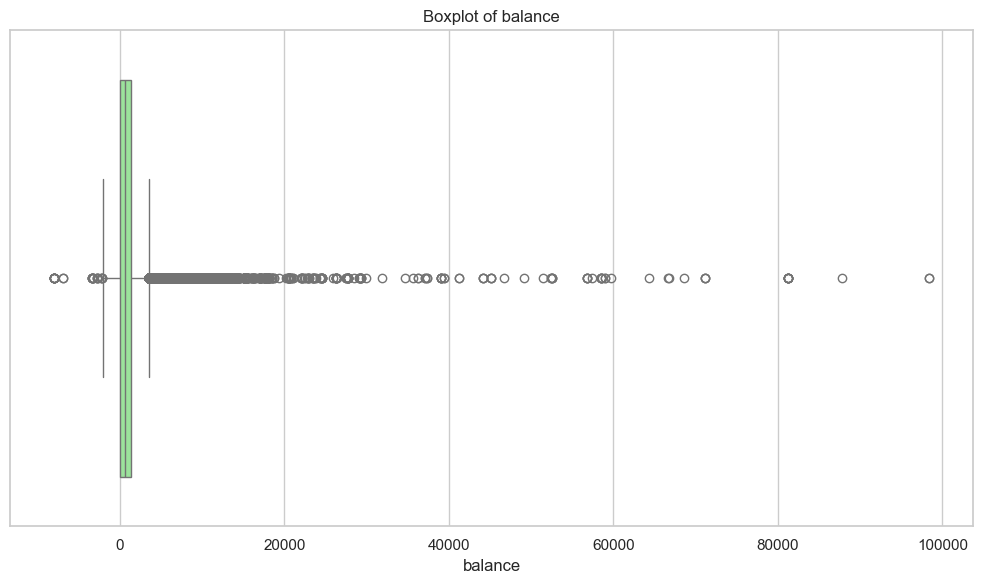

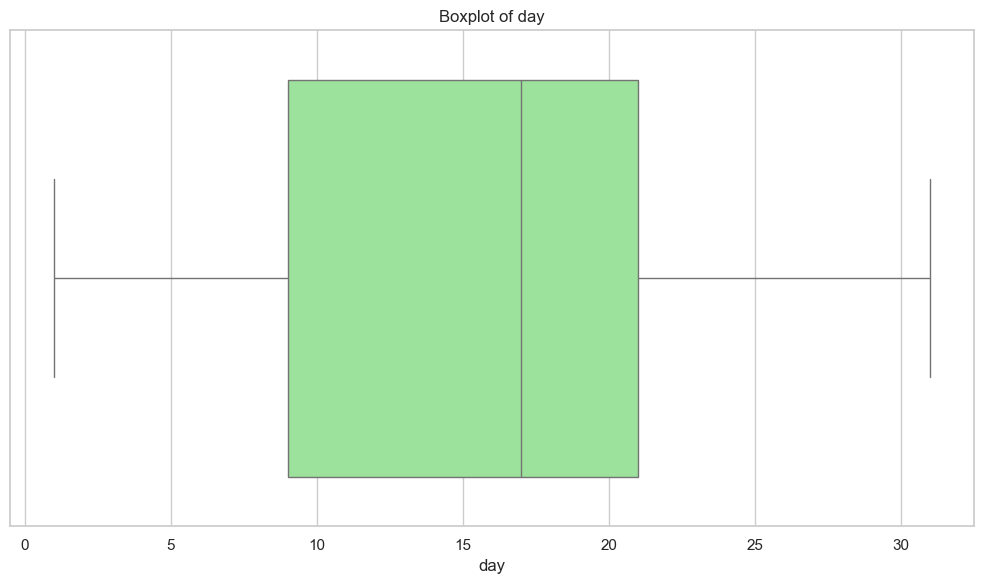

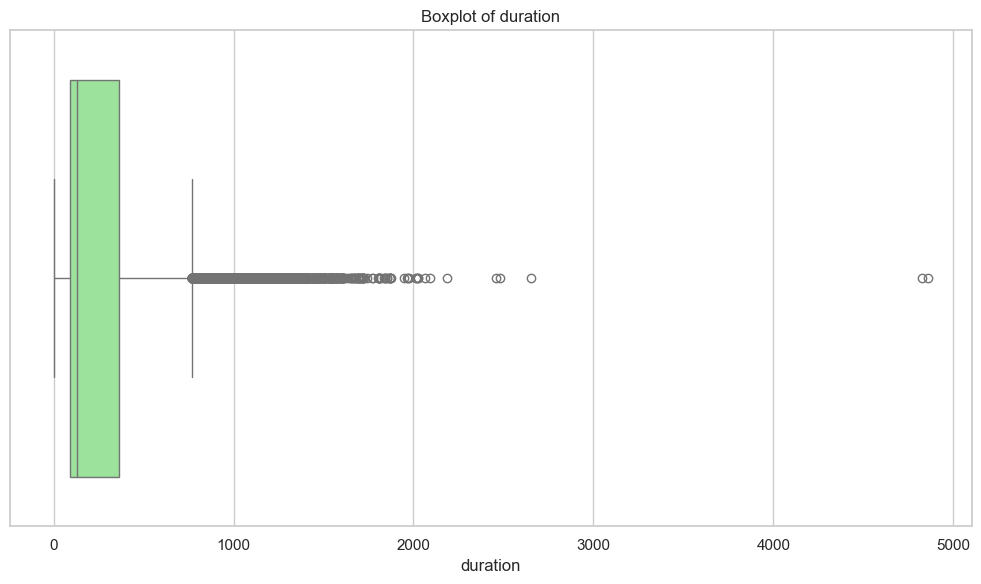

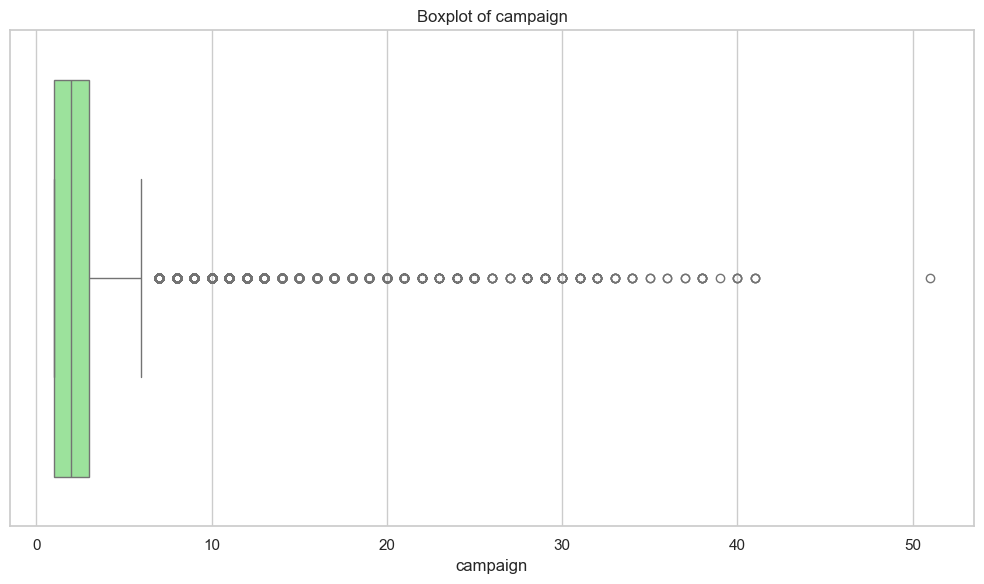

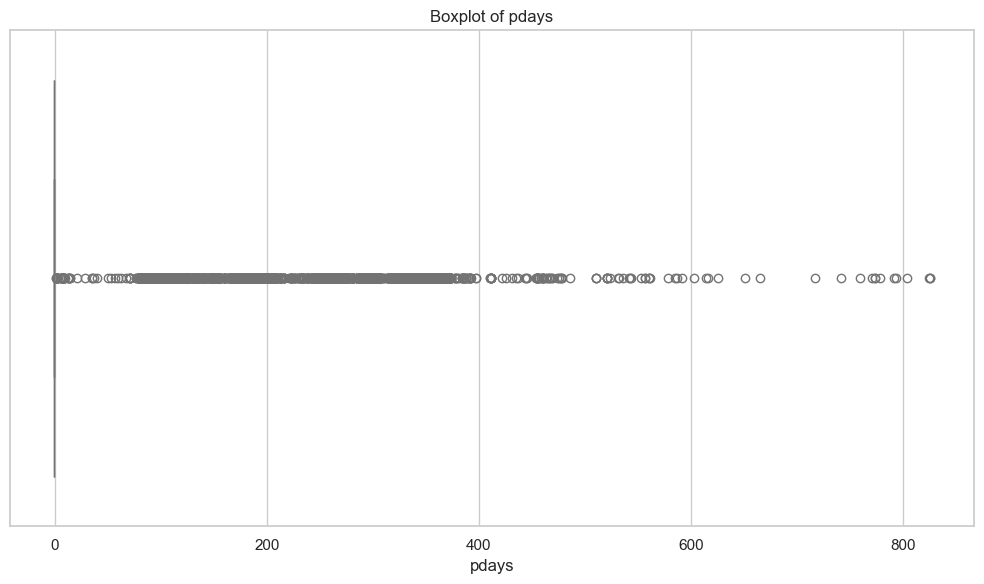

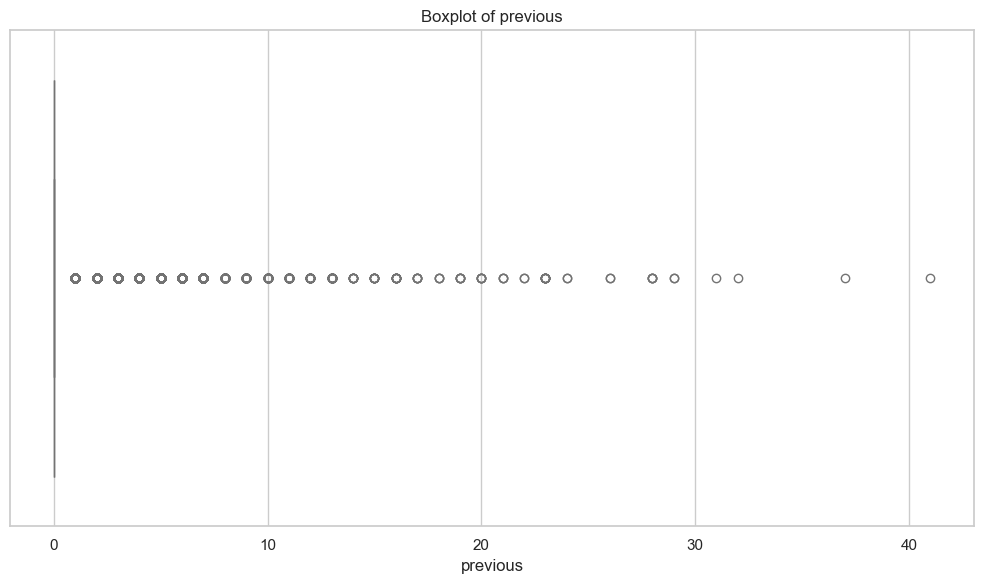

Step 9 Completed: Individual boxplots generated and saved.
Key Finding: Visual confirmation of extreme outliers in 'balance' and 'duration'.



In [10]:
# ==============================================================================
# Step 9: Numerical Feature Boxplots: Outlier View (Separate Graphs)
# ==============================================================================
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=sample_df, x=col, color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.savefig(f'../charts/03_Num_Boxplot_{col}.png', bbox_inches='tight')
    plt.show()
    plt.close()

print("Step 9 Completed: Individual boxplots generated and saved.")
print("Key Finding: Visual confirmation of extreme outliers in 'balance' and 'duration'.\n")


In [11]:
# ==============================================================================
# Step 10: Outlier Check Using IQR Method
# ==============================================================================
print("--- Outlier Detection (IQR Method) ---")
outlier_dict = {}
for col in numerical_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)].shape[0]
    outlier_dict[col] = outliers
    
outlier_df = pd.DataFrame(list(outlier_dict.items()), columns=['Feature', 'Outlier_Count'])
outlier_df['Outlier_Percentage'] = (outlier_df['Outlier_Count'] / len(train_df)) * 100
display(outlier_df.sort_values(by='Outlier_Percentage', ascending=False))

print("Step 10 Completed: Outliers quantified using IQR.")
print("Key Finding: Features like 'previous' and 'pdays' have a high percentage of statistical outliers because most customers have not been contacted before (zeros and -1s).\n")


--- Outlier Detection (IQR Method) ---


,Feature,Outlier_Count,Outlier_Percentage
6,previous,77569,10.342533
5,pdays,77566,10.342133
1,balance,57745,7.699333
3,duration,46118,6.149067
4,campaign,40686,5.424800
0,age,4903,0.653733
2,day,0,0.000000


Step 10 Completed: Outliers quantified using IQR.
Key Finding: Features like 'previous' and 'pdays' have a high percentage of statistical outliers because most customers have not been contacted before (zeros and -1s).



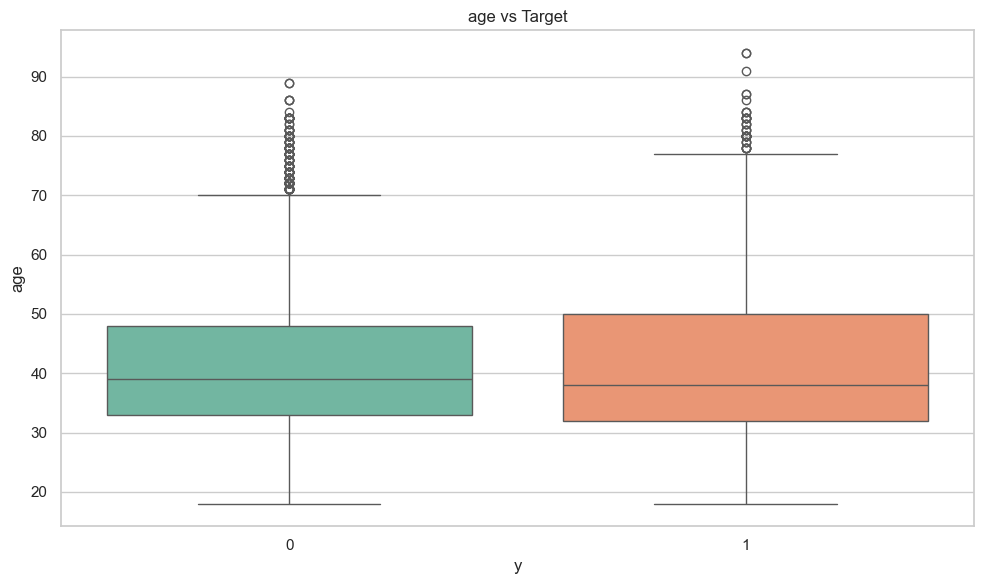

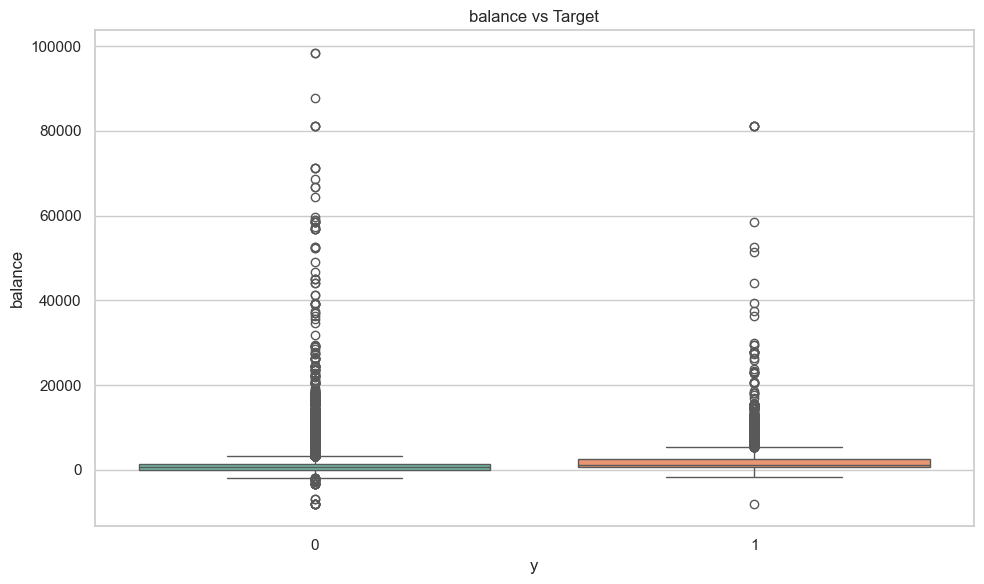

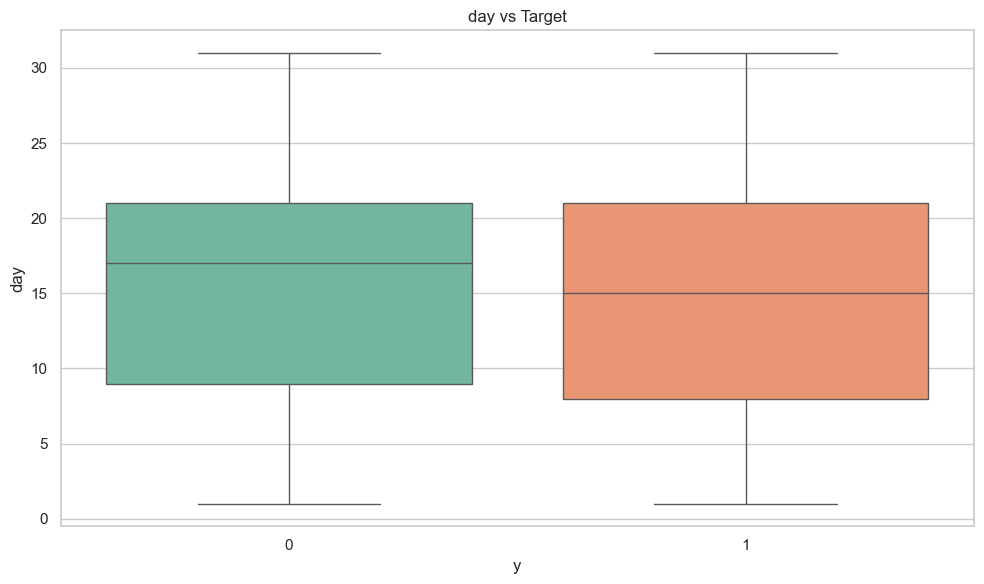

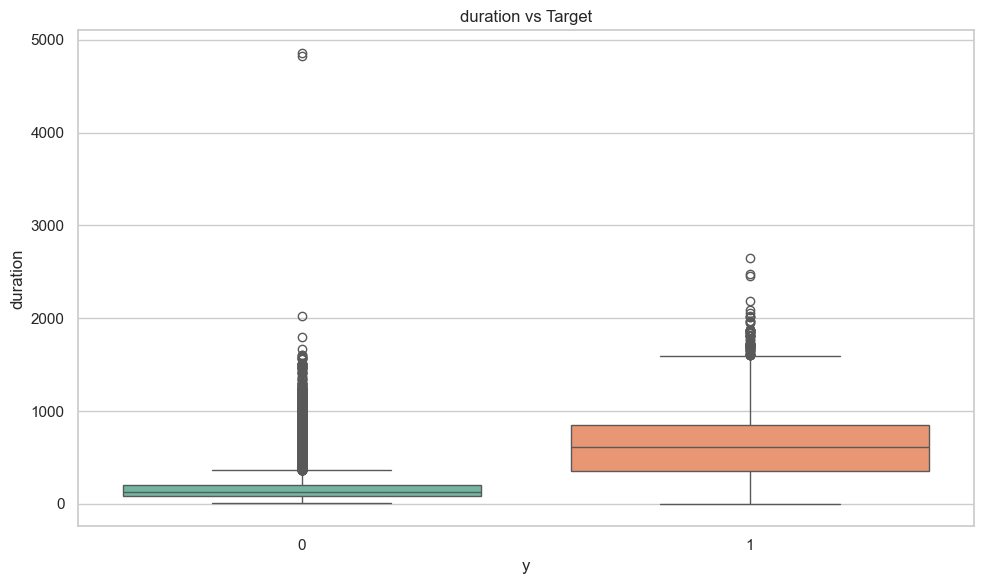

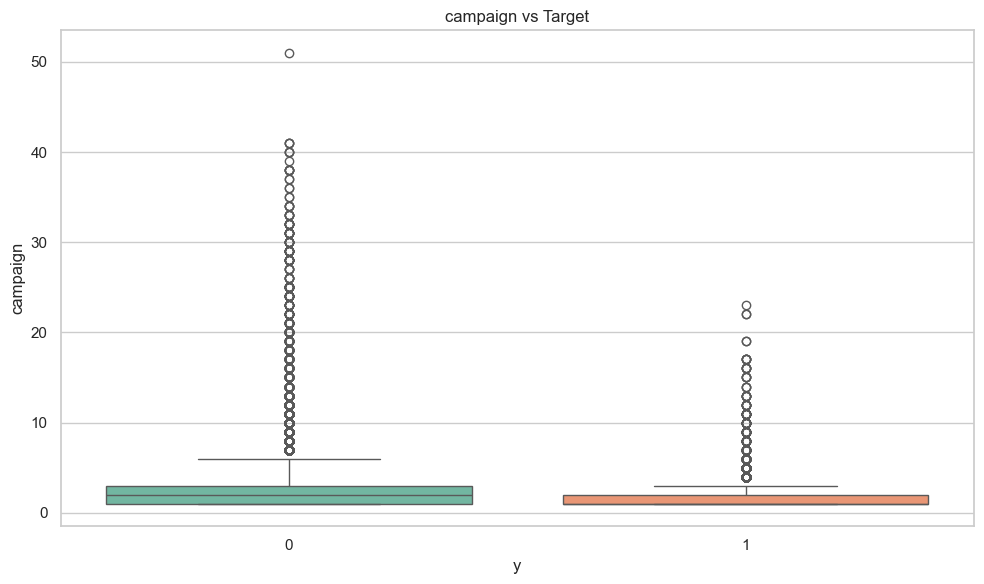

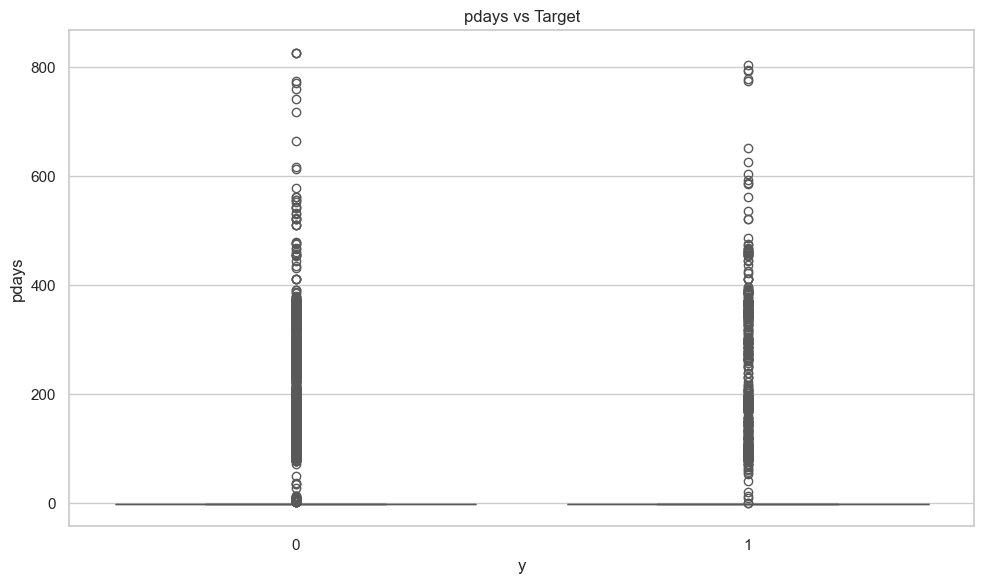

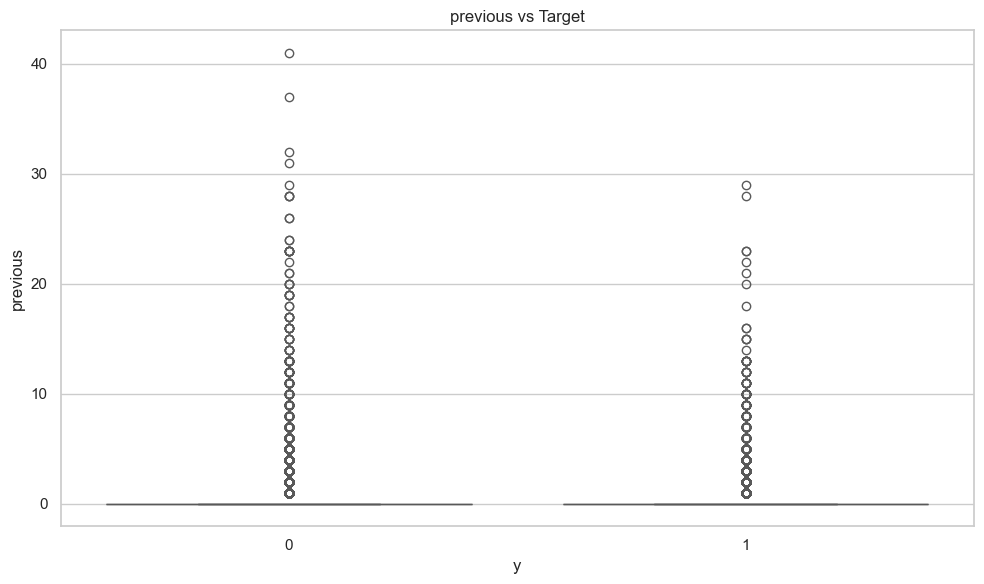

y                          0            1
age      mean      40.890771    41.186036
         median    39.000000    38.000000
balance  mean    1075.364679  2142.103240
         median   584.000000  1134.000000
day      mean      16.268873    15.011825
         median    17.000000    15.000000
duration mean     203.803576   638.327226
         median   123.000000   609.000000
campaign mean       2.653365     2.020489
         median     2.000000     1.000000
pdays    mean      19.855833    41.048426
         median    -1.000000    -1.000000
previous mean       0.239386     0.729721
         median     0.000000     0.000000

Step 11 Completed: Bivariate numerical analysis with target plotted and saved individually.
Key Finding: Customers who subscribe (y=1) tend to have significantly higher call 'duration' and higher 'balance' on average.



In [12]:
# ==============================================================================
# Step 11: Numerical Features vs Target: Boxplots (Separate Graphs)
# ==============================================================================
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=sample_df, x=TARGET, y=col, palette='Set2')
    plt.title(f"{col} vs Target")
    plt.tight_layout()
    plt.savefig(f'../charts/04_Num_vs_Target_{col}.png', bbox_inches='tight')
    plt.show()
    plt.close()

mean_median_comp = train_df.groupby(TARGET)[numerical_cols].agg(['mean', 'median']).T
display(mean_median_comp)

print("Step 11 Completed: Bivariate numerical analysis with target plotted and saved individually.")
print("Key Finding: Customers who subscribe (y=1) tend to have significantly higher call 'duration' and higher 'balance' on average.\n")


In [13]:
# ==============================================================================
# Step 12: Categorical Feature Summary & Unknown Values
# ==============================================================================
display(train_df[categorical_cols].describe().T)

print("\n--- Structural 'Unknown' Check ---")
unknown_summary = []
for col in categorical_cols:
    unknown_count = (train_df[col] == "unknown").sum()
    if unknown_count > 0:
        unknown_summary.append({"Feature": col, "Unknown Count": unknown_count, "Unknown %": round((unknown_count/len(train_df))*100, 2)})

if unknown_summary:
    display(pd.DataFrame(unknown_summary).sort_values("Unknown Count", ascending=False))
else:
    print("No 'unknown' string values found in categorical columns.")

print("Step 12 Completed: Categorical summaries and structural missing values (unknowns) checked.")
print("Key Finding: 'poutcome' is dominated by 'unknown' values (approx 89%). This is natural for customers not part of a previous campaign.\n")


,count,unique,top,freq
job,750000,12,management,175541
marital,750000,3,married,480759
education,750000,4,secondary,401683
default,750000,2,no,737151
housing,750000,2,yes,411288
loan,750000,2,no,645023
contact,750000,3,cellular,486655
month,750000,12,may,228411
poutcome,750000,4,unknown,672450



--- Structural 'Unknown' Check ---


,Feature,Unknown Count,Unknown %
3,poutcome,672450,89.66
2,contact,231627,30.88
1,education,21299,2.84
0,job,2917,0.39


Step 12 Completed: Categorical summaries and structural missing values (unknowns) checked.
Key Finding: 'poutcome' is dominated by 'unknown' values (approx 89%). This is natural for customers not part of a previous campaign.



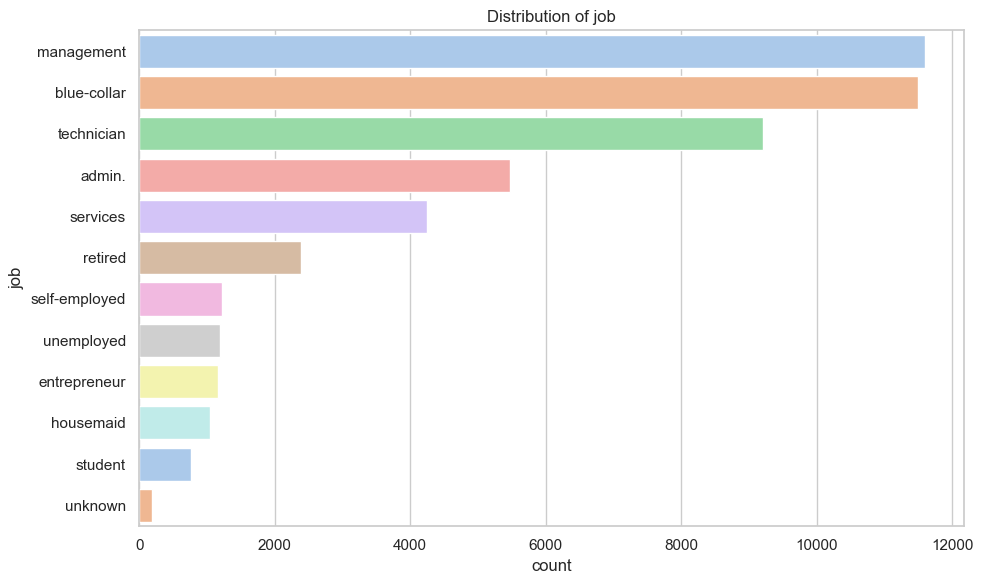

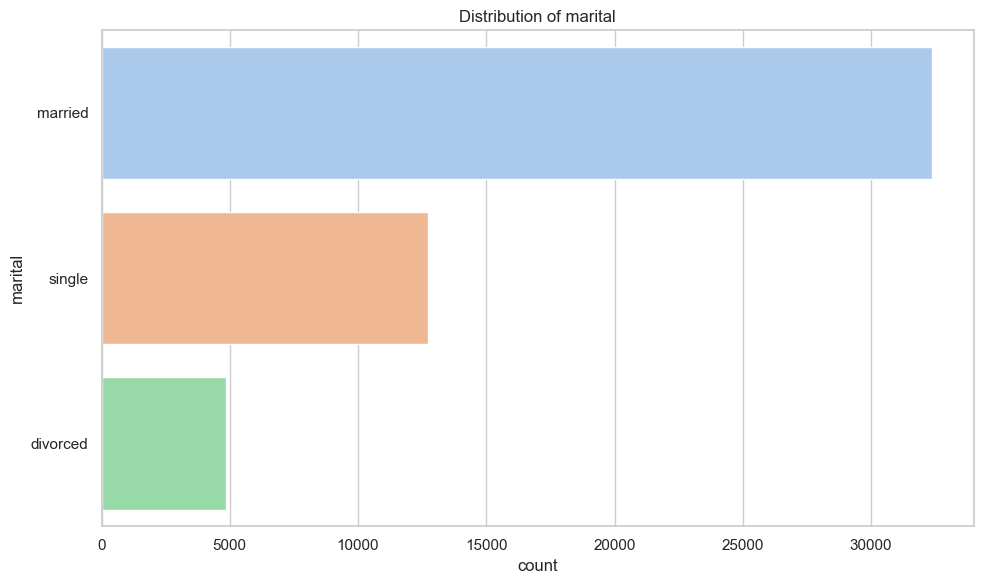

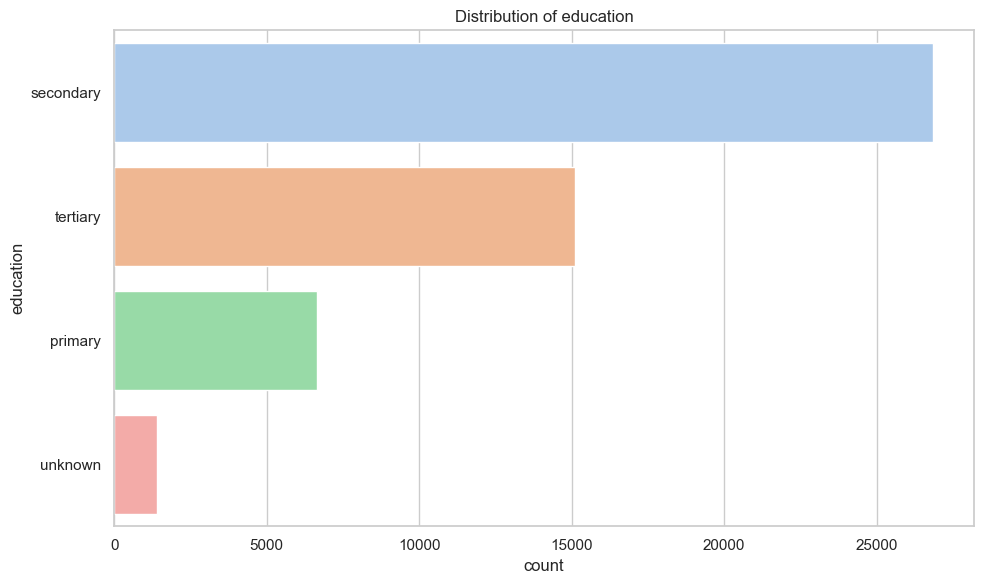

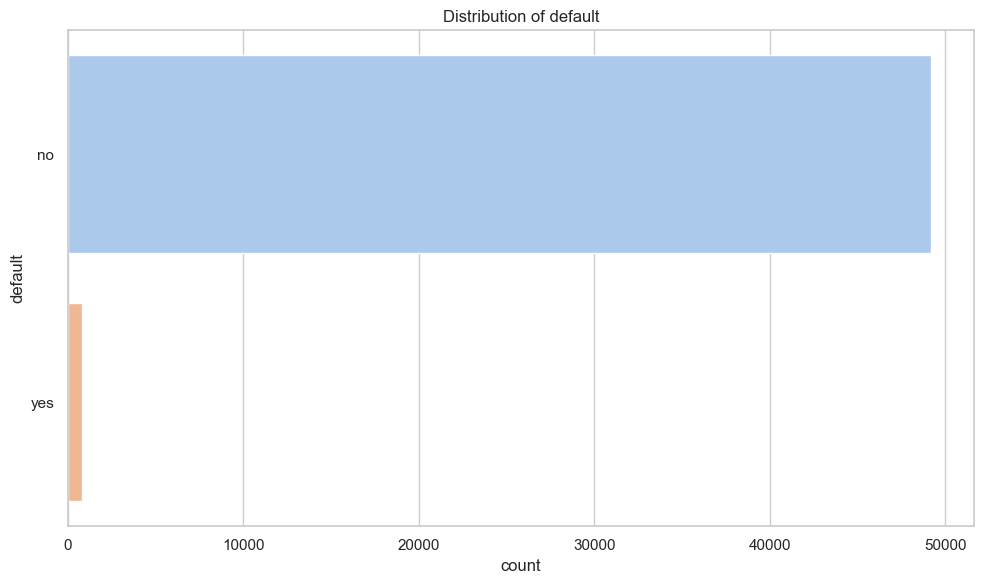

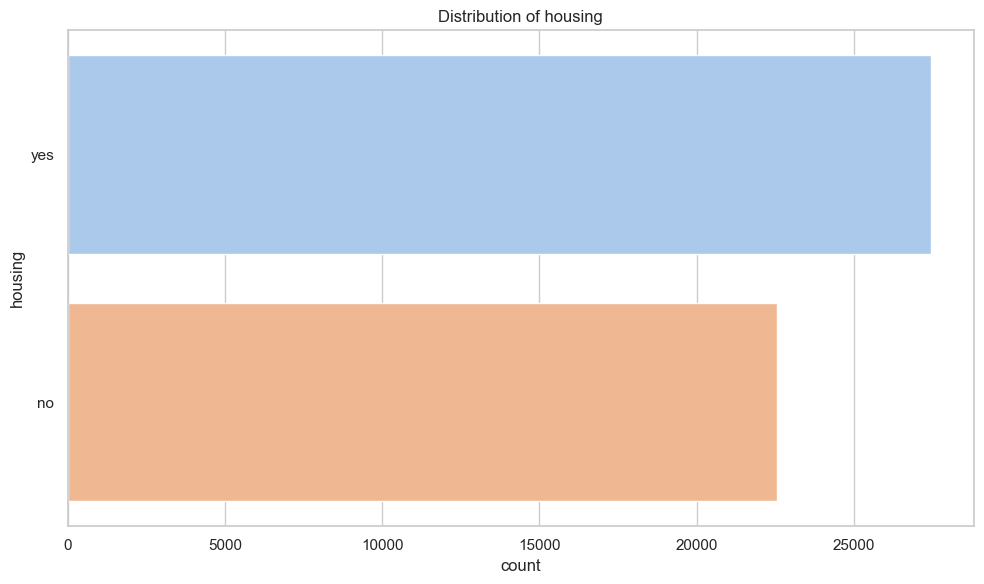

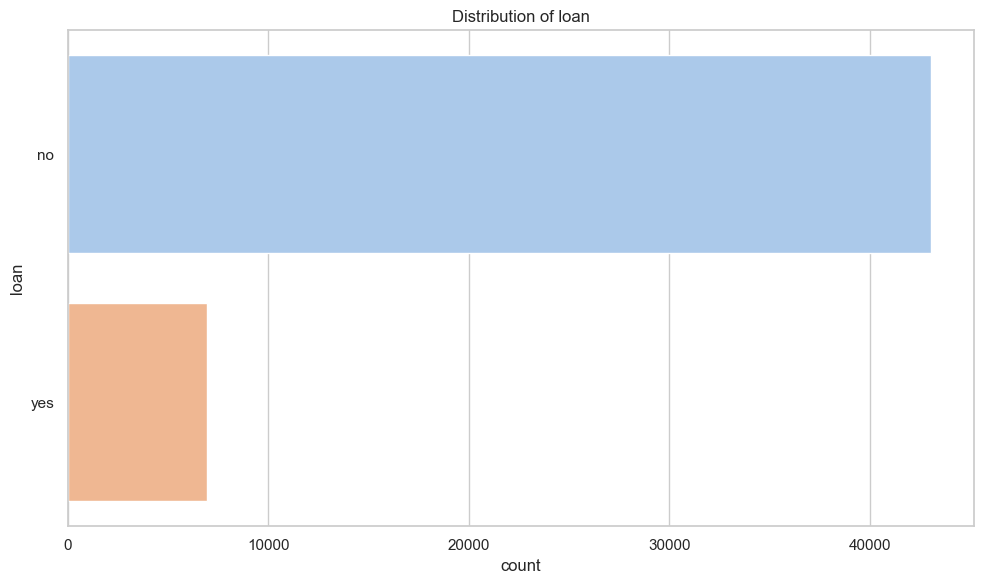

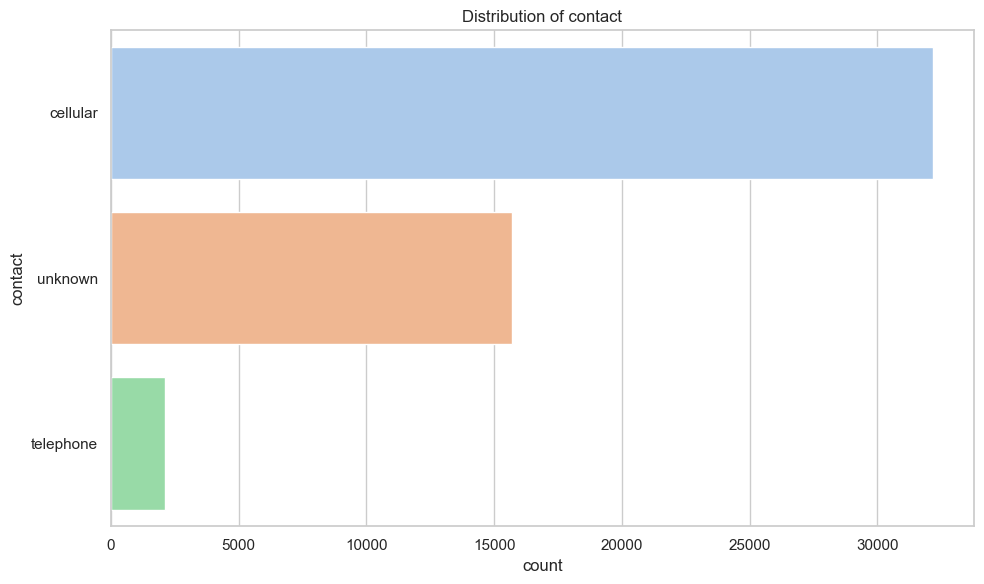

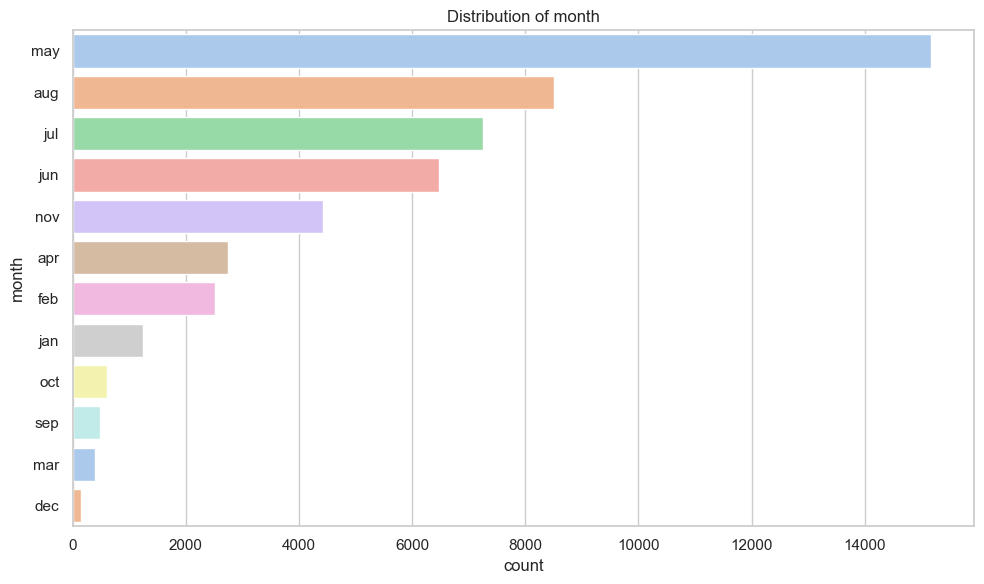

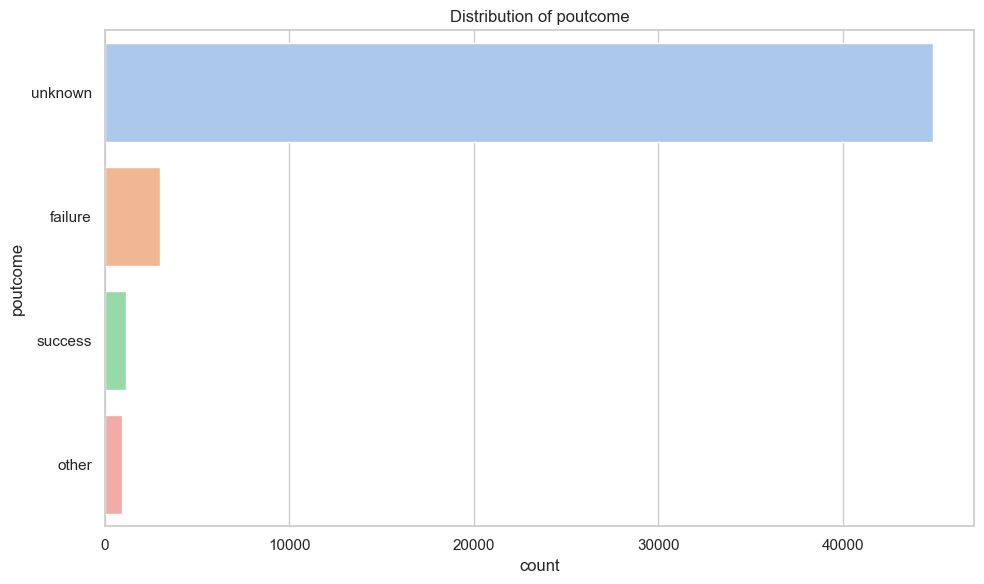

Step 13 Completed: Individual categorical distributions plotted and saved.
Key Finding: Most customers have 'secondary' education, 'management' or 'blue-collar' jobs, and are contacted via 'cellular'.



In [14]:
# ==============================================================================
# Step 13: Categorical Feature Countplots (Separate Graphs)
# ==============================================================================
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=sample_df, y=col, palette='pastel', order=sample_df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.savefig(f'../charts/05_Cat_Countplot_{col}.png', bbox_inches='tight')
    plt.show()
    plt.close()

print("Step 13 Completed: Individual categorical distributions plotted and saved.")
print("Key Finding: Most customers have 'secondary' education, 'management' or 'blue-collar' jobs, and are contacted via 'cellular'.\n")


<Figure size 1200x600 with 0 Axes>

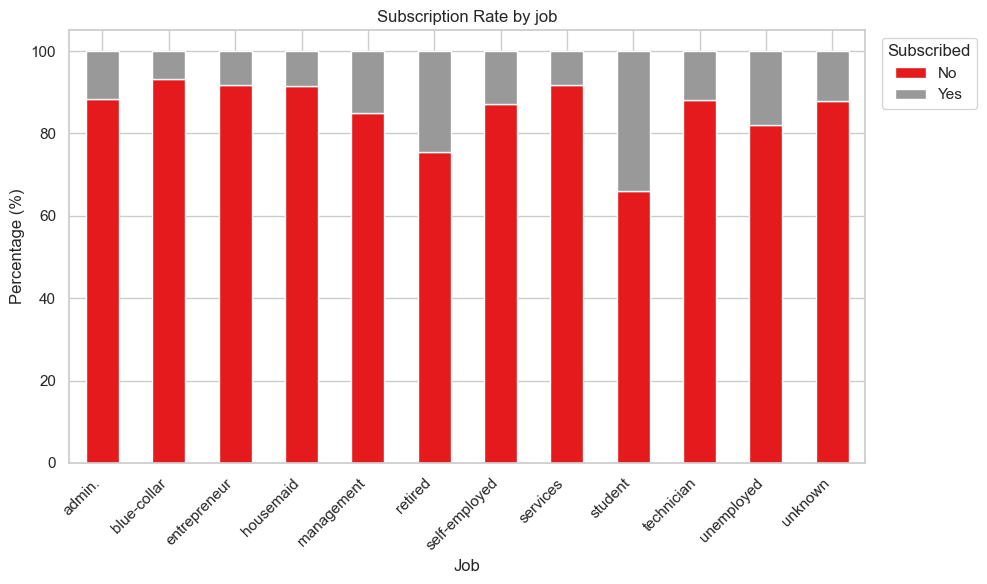

<Figure size 1200x600 with 0 Axes>

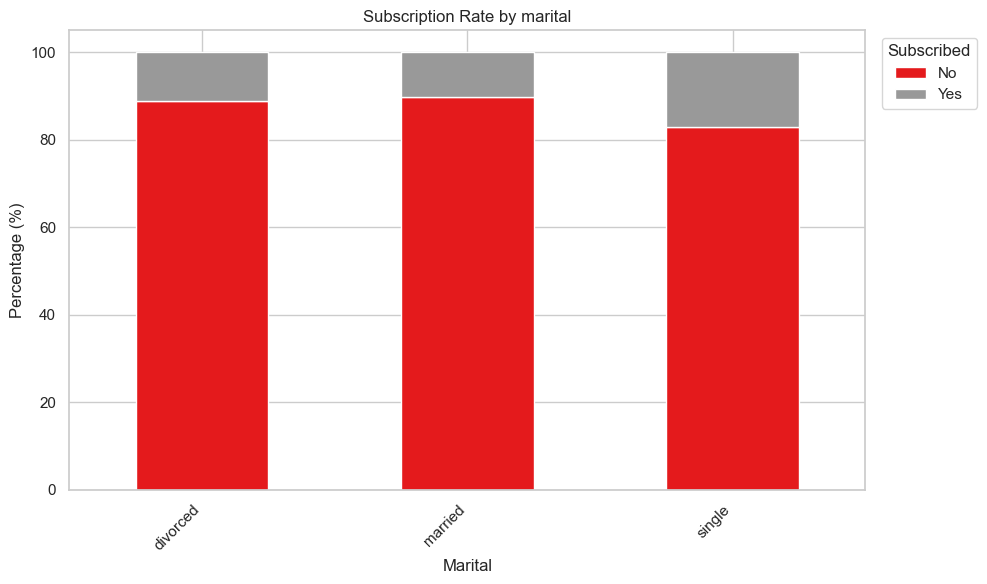

<Figure size 1200x600 with 0 Axes>

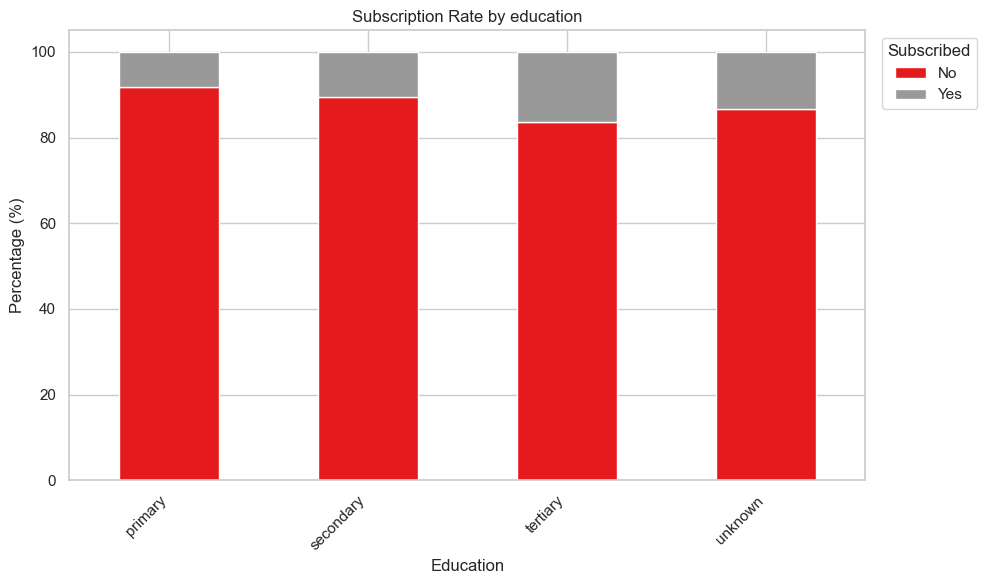

<Figure size 1200x600 with 0 Axes>

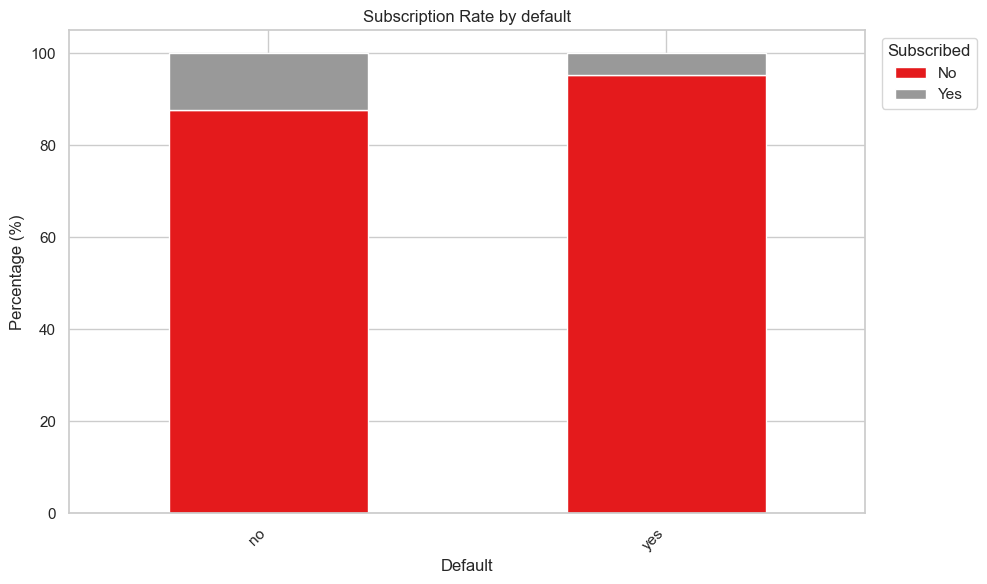

<Figure size 1200x600 with 0 Axes>

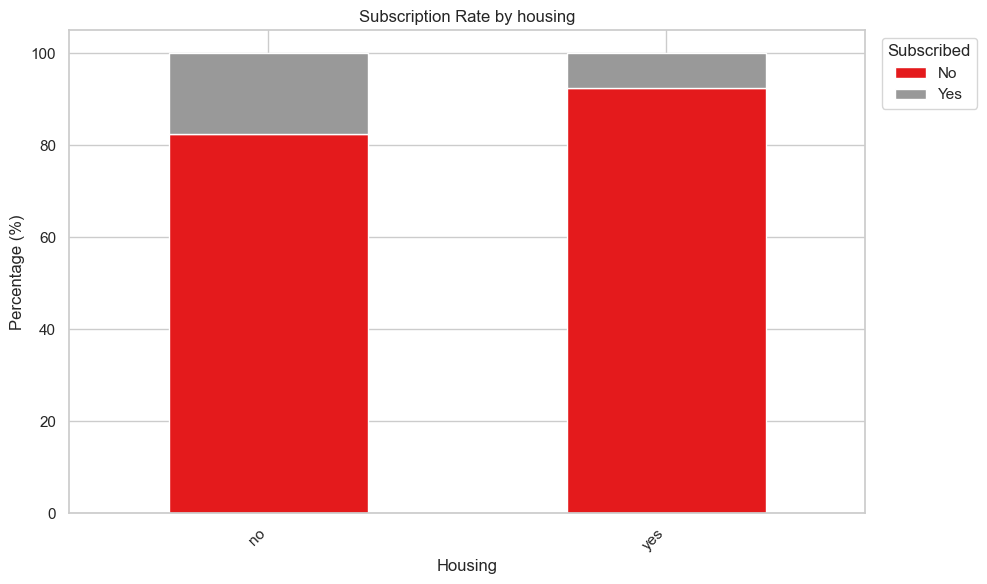

<Figure size 1200x600 with 0 Axes>

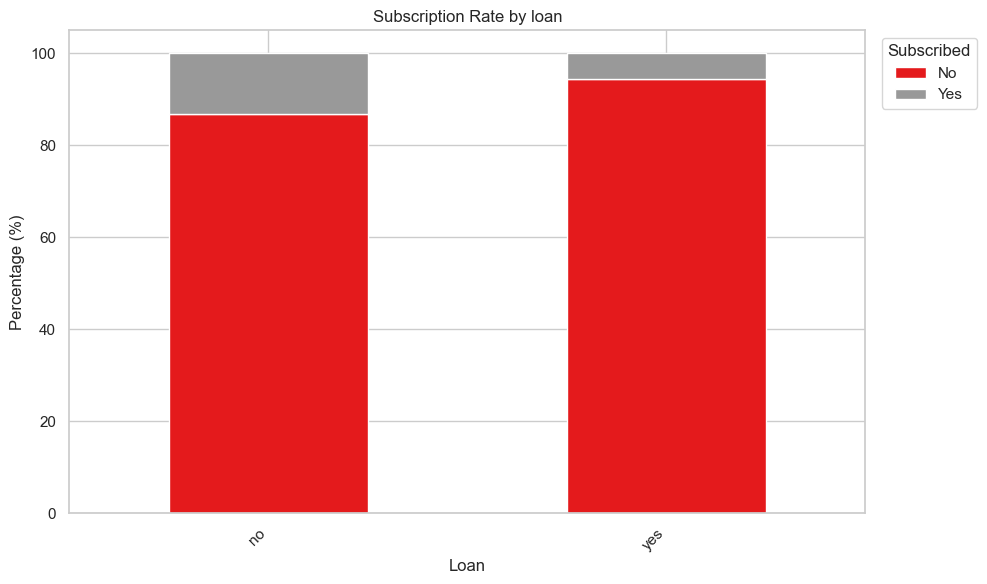

<Figure size 1200x600 with 0 Axes>

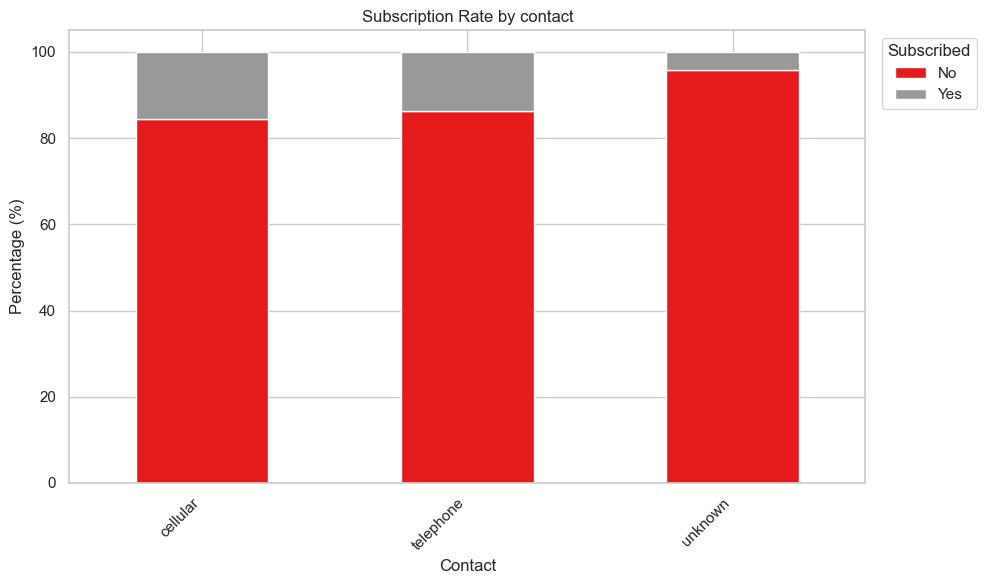

<Figure size 1200x600 with 0 Axes>

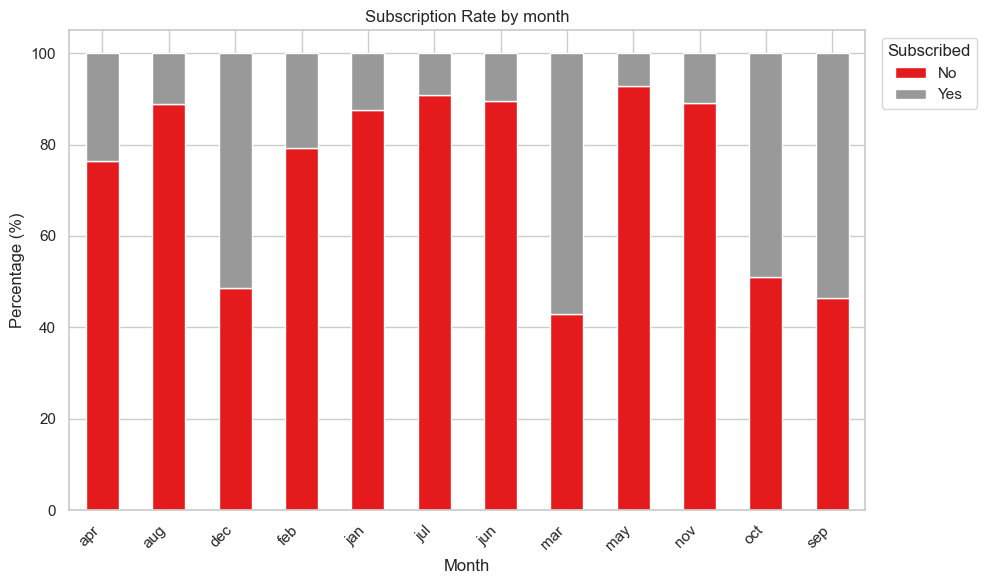

<Figure size 1200x600 with 0 Axes>

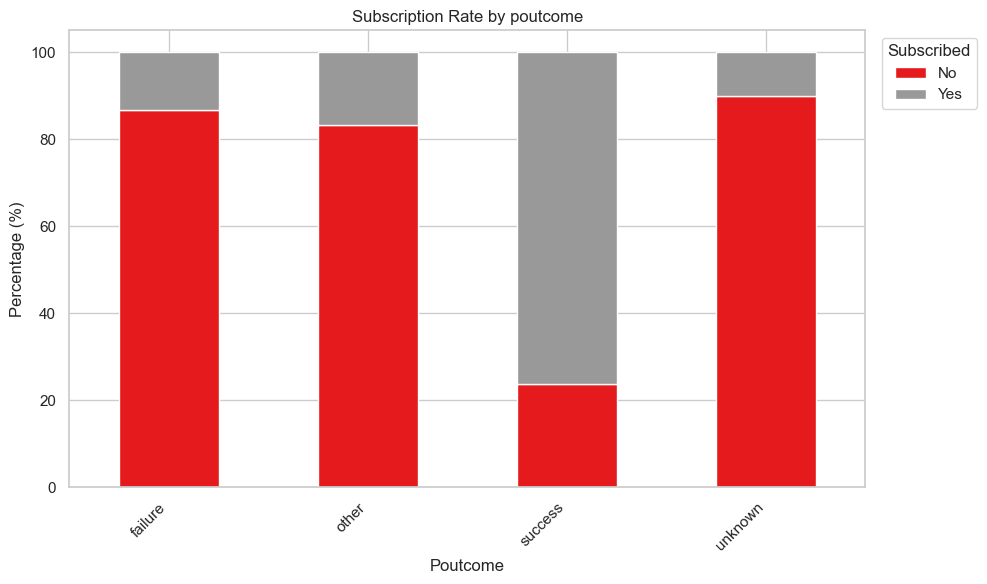

Step 14 Completed: Subscription rates for all categorical features mapped and saved individually.
Key Finding: Students and retired individuals show a proportionally higher subscription rate compared to blue-collar workers.



In [15]:
# ==============================================================================
# Step 14: Categorical Features vs Target: Stacked Percentage Bars (All Features)
# ==============================================================================
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    crosstab = pd.crosstab(train_df[col], train_df[TARGET], normalize='index') * 100
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1')
    
    plt.title(f"Subscription Rate by {col}")
    plt.ylabel("Percentage (%)")
    plt.xlabel(col.capitalize())
    plt.xticks(rotation=45, ha='right')  # Rotates labels so they don't overlap
    plt.legend(title="Subscribed", labels=['No', 'Yes'], loc='upper right', bbox_to_anchor=(1.15, 1))
    
    plt.tight_layout()
    plt.savefig(f'../charts/06_Cat_vs_Target_{col}.png', bbox_inches='tight')
    plt.show()
    plt.close()

print("Step 14 Completed: Subscription rates for all categorical features mapped and saved individually.")
print("Key Finding: Students and retired individuals show a proportionally higher subscription rate compared to blue-collar workers.\n")


--- Generating Scatterplots (Numerical vs Balance, colored by Target) ---


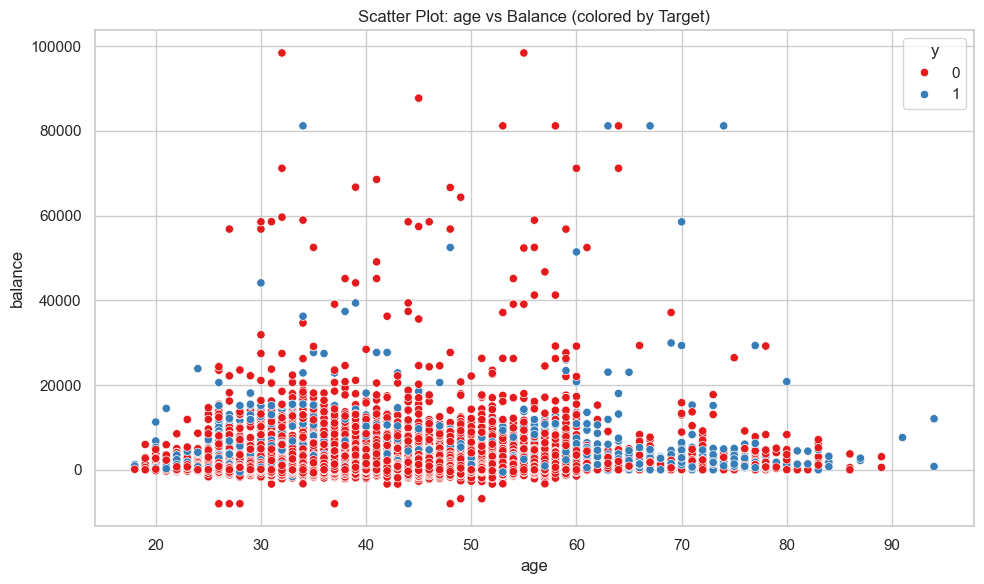

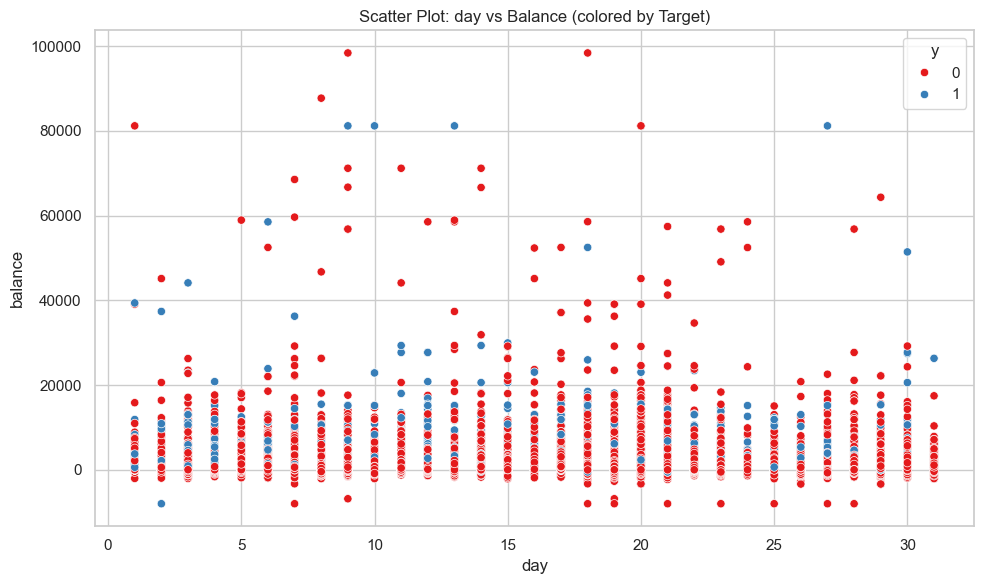

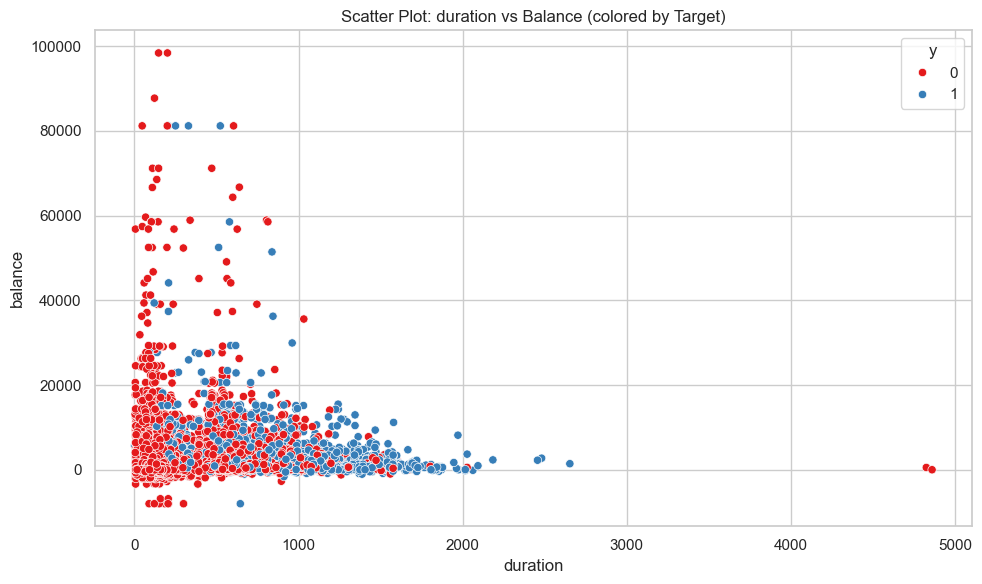

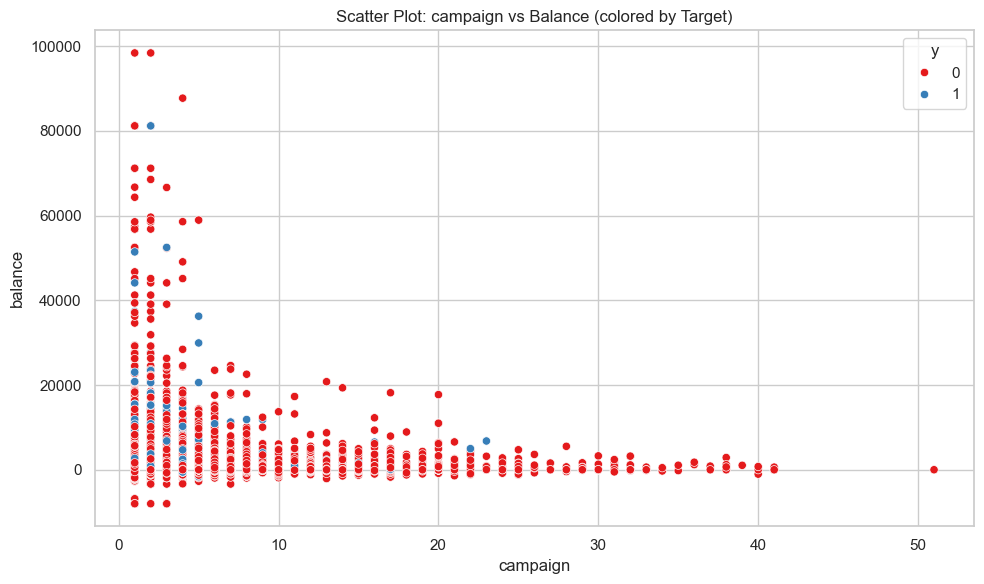

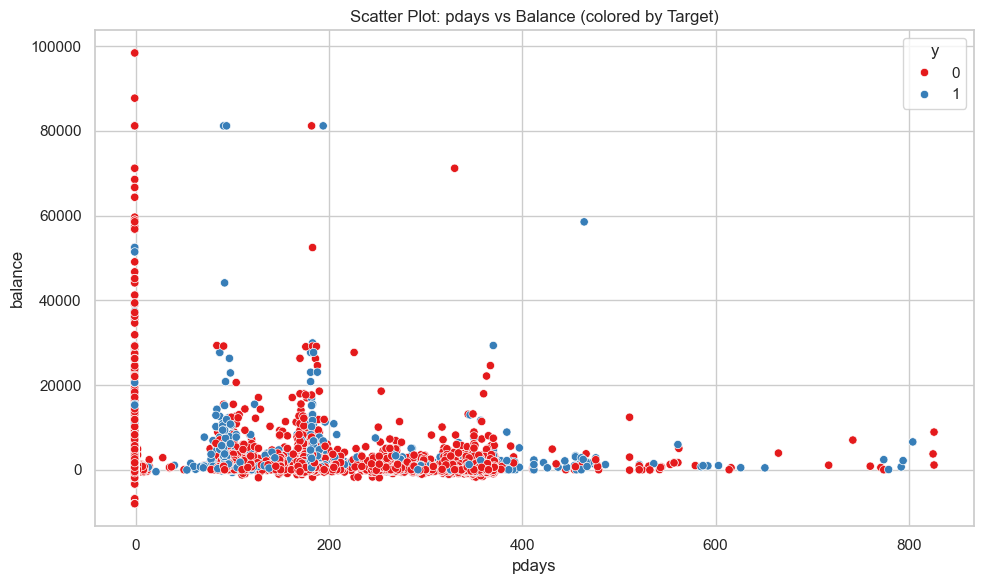

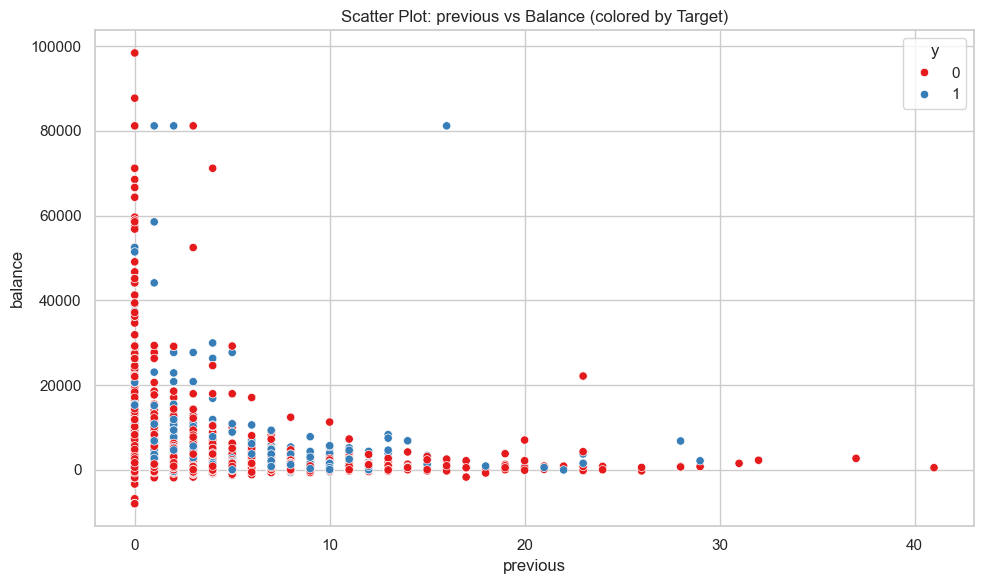

Step 15 Completed: Scatterplots generated to visualize multidimensional boundaries.



In [16]:
# ==============================================================================
# Step 15: Bivariate Analysis - Scatterplots for Numerical Features
# ==============================================================================
print("--- Generating Scatterplots (Numerical vs Balance, colored by Target) ---")
# Using 'balance' as the Y-axis to evaluate interactions with other continuous features
for col in numerical_cols:
    if col != 'balance':
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=sample_df, x=col, y='balance', hue=TARGET, alpha=1.0, palette='Set1')
        plt.title(f"Scatter Plot: {col} vs Balance (colored by Target)")
        plt.tight_layout()
        plt.savefig(f'../charts/07_Scatter_{col}_vs_balance.png', bbox_inches='tight')
        plt.show()
        plt.close()

print("Step 15 Completed: Scatterplots generated to visualize multidimensional boundaries.\n")


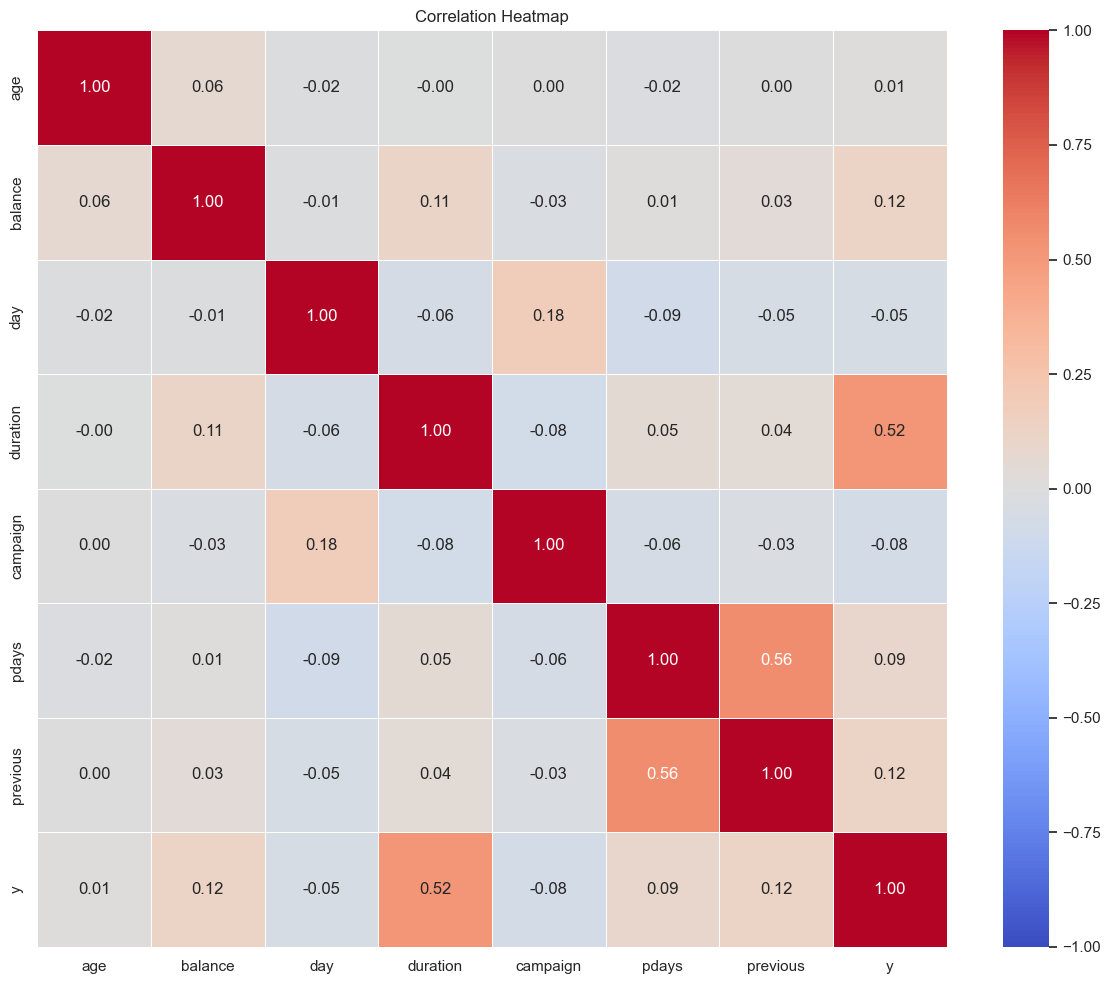

Step 16 Completed: Correlation heatmap generated and saved.
Key Finding: 'duration' shows the strongest positive linear correlation with the target. 'pdays' and 'previous' are highly collinear.



In [17]:
# ==============================================================================
# Step 16: Correlation Analysis for Numerical Features
# ==============================================================================
plt.figure(figsize=(12, 10))
corr_matrix = train_df[numerical_cols + [TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('../charts/07_Correlation_Heatmap.png', bbox_inches='tight')
plt.show()
plt.close()

print("Step 16 Completed: Correlation heatmap generated and saved.")
print("Key Finding: 'duration' shows the strongest positive linear correlation with the target. 'pdays' and 'previous' are highly collinear.\n")


--- Generating Pair Plot ---


<Figure size 1600x1200 with 0 Axes>

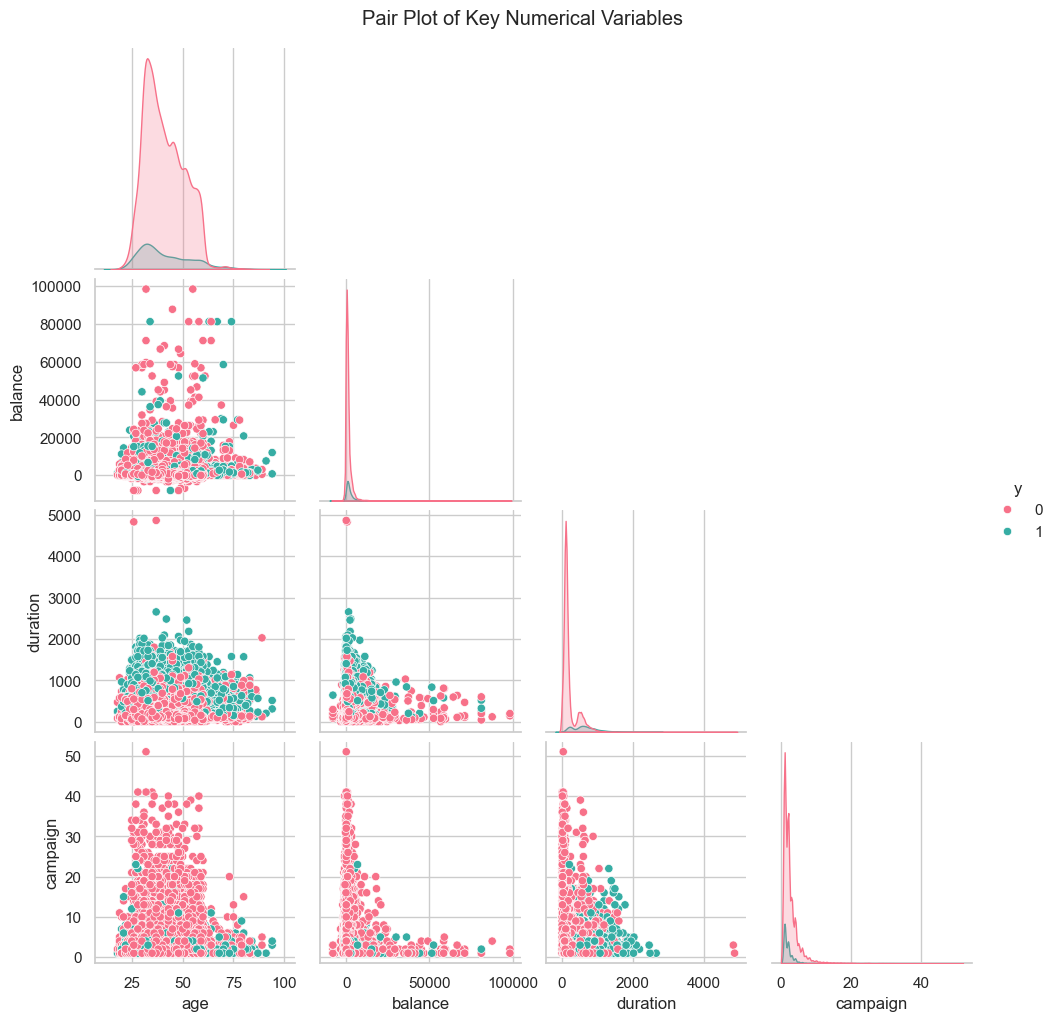

Step 17 Completed: Pair plot generated mapping global feature interactions.



In [18]:
# ==============================================================================
# Step 17: Multivariate Analysis - Pair Plot
# ==============================================================================
print("--- Generating Pair Plot ---")
# Utilizing key numerical variables to evaluate comprehensive interactions
top_num_cols = ['age', 'balance', 'duration', 'campaign']
plt.figure(figsize=(16, 12))
sns.pairplot(sample_df[top_num_cols + [TARGET]], hue=TARGET, palette='husl', corner=True)
plt.suptitle("Pair Plot of Key Numerical Variables", y=1.02)
plt.savefig('../charts/09_Pairplot.png', bbox_inches='tight')
plt.show()
plt.close()

print("Step 17 Completed: Pair plot generated mapping global feature interactions.\n")


In [19]:
# ==============================================================================
# Step 18: Final EDA Summary Before Modeling
# ==============================================================================
print("""
Step 18 Completed: Final EDA Summary.
=========================================
1. The target 'y' is heavily imbalanced. Evaluation should rely on PR-AUC, F1-Score, and ROC-AUC, NOT just accuracy.
2. 'duration' is the strongest predictor but is unknown before a call. (In real business use-cases, we might drop this to predict *before* dialing, but for Kaggle, keep it!).
3. Standard scaling is required for numerical features due to vast scale differences (e.g., balance vs. campaign).
4. Missing structural values ('unknown') will be treated as independent categories.
""")



Step 18 Completed: Final EDA Summary.
1. The target 'y' is heavily imbalanced. Evaluation should rely on PR-AUC, F1-Score, and ROC-AUC, NOT just accuracy.
2. 'duration' is the strongest predictor but is unknown before a call. (In real business use-cases, we might drop this to predict *before* dialing, but for Kaggle, keep it!).
3. Standard scaling is required for numerical features due to vast scale differences (e.g., balance vs. campaign).
4. Missing structural values ('unknown') will be treated as independent categories.

